0.003472768590017064 0.017970820695715817 30.095289611514417
0.003472768590017064 0.010375458166230025 30.095289611514545
0.003472768590017064 0.005682872482095371 30.095289611514545
0.003472768590017064 0.003281007957308079 30.095289611514545
0.003472768590017064 0.001797082069571582 30.09528961151448
0.003472768590017064 0.000568287248209537 30.095289611514545


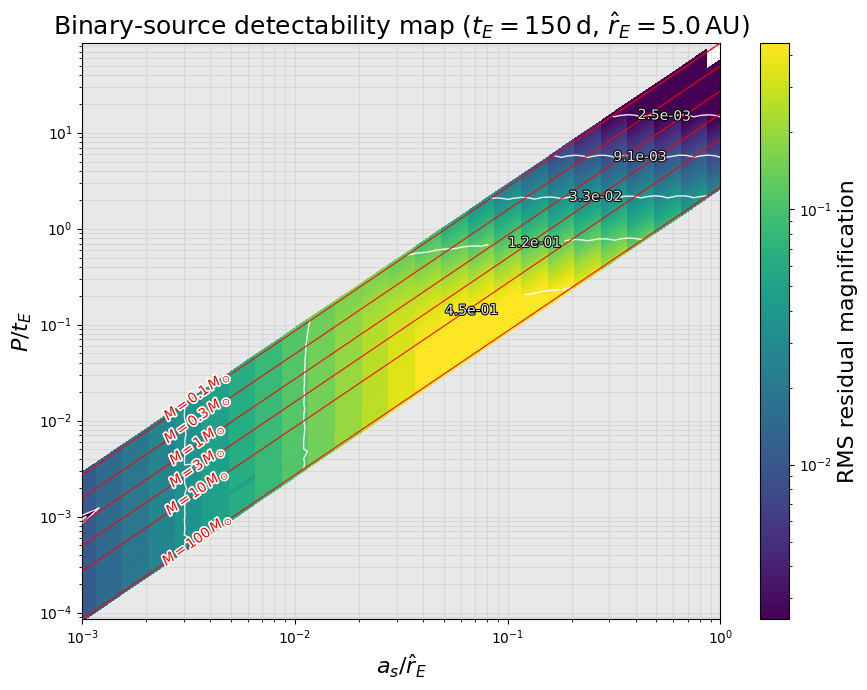

In [52]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patheffects as pe

# ============================================================
# Parámetros del barrido
# ============================================================
tE_true = 150.0
rEhat_AU = 5.0

# Estas grillas DEBEN coincidir con las del script de generación
a_over_RE_grid = np.logspace(-3, 0, 25)
Mtot_grid = np.logspace(-1, 2, 30)   # 0.1 a 100 Msun

# rango "físico" que querés remarcar en la figura
Mmin_phys = 0.1
Mmax_phys = 10.0

pattern = f"/home/anibal-pc/binary_source/results/scan_aRE_Mtot_tE{int(tE_true)}/scan_aRE_*_Mtot_*.npz"
files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# Parseo de índices desde nombre de archivo
# ============================================================
def extract_indices_from_filename(filename):
    """
    Extrae ia e im desde:
    scan_aRE_003_Mtot_015.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_aRE_(\d+)_Mtot_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear índices desde: {base}")
    ia = int(m.group(1))
    im = int(m.group(2))
    return ia, im

# ============================================================
# Función para bordes logarítmicos
# ============================================================
def log_bin_edges(x):
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("Todos los valores deben ser positivos.")
    lx = np.log10(x)
    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5 * (lx[1] - lx[0])
    edges[-1] = lx[-1] + 0.5 * (lx[-1] - lx[-2])
    return 10**edges

# ============================================================
# Reconstrucción de matrices en la grilla (a_over_RE, Mtot)
# ============================================================
Na = len(a_over_RE_grid)
Nm = len(Mtot_grid)

RMS_map = np.full((Na, Nm), np.nan, dtype=float)
P_over_tE_map = np.full((Na, Nm), np.nan, dtype=float)

for fn in files:
    ia, im = extract_indices_from_filename(fn)

    if not (0 <= ia < Na and 0 <= im < Nm):
        continue

    d = np.load(fn, allow_pickle=False)

    P_grid_file = d["P_grid"].astype(float)
    RMS = d["MAXABS"].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    m = SUCCESS & np.isfinite(P_grid_file) & np.isfinite(RMS)
    if not np.any(m):
        continue

    P_day = float(P_grid_file[m][0])
    rms_val = float(RMS[m][0])

    RMS_map[ia, im] = rms_val
    P_over_tE_map[ia, im] = P_day / tE_true

# ============================================================
# Coordenadas de la grilla en el plano (a_s/R_E, P/t_E)
# ============================================================
A_grid, M_grid = np.meshgrid(a_over_RE_grid, Mtot_grid, indexing="ij")
a_AU_grid = A_grid * rEhat_AU
P_yr_grid = np.sqrt(a_AU_grid**3 / M_grid)
P_day_grid = 365.25 * P_yr_grid
P_over_tE_grid = P_day_grid / tE_true

# ============================================================
# Limpieza conservadora de artefactos de borde
# ============================================================
RMS_map[~np.isfinite(RMS_map)] = np.nan
RMS_map[RMS_map <= 0] = np.nan

positive_all = RMS_map[np.isfinite(RMS_map)]
if len(positive_all) == 0:
    raise RuntimeError("No hay valores positivos de RMS para graficar.")

tiny_threshold = np.percentile(positive_all, 0.5)

border_mask = np.zeros_like(RMS_map, dtype=bool)
border_mask[0, :] = True
border_mask[-1, :] = True
border_mask[:, 0] = True
border_mask[:, -1] = True

RMS_map[border_mask & np.isfinite(RMS_map) & (RMS_map < tiny_threshold)] = np.nan

# ============================================================
# Normalización de color
# ============================================================
positive = RMS_map[np.isfinite(RMS_map) & (RMS_map > 0)]
if len(positive) == 0:
    raise RuntimeError("No quedaron valores positivos de RMS luego de limpiar el mapa.")

vmin = np.percentile(positive, 5)
vmax = np.percentile(positive, 95)

# evita problemas si por percentiles quedan iguales
if vmin <= 0 or vmax <= 0 or np.isclose(vmin, vmax):
    vmin = np.nanmin(positive)
    vmax = np.nanmax(positive)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ============================================================
# Figura
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

# ============================================================
# Fondo gris no físico
# ============================================================
x_curve = np.logspace(
    np.log10(a_over_RE_grid.min()),
    np.log10(a_over_RE_grid.max()),
    800
)

def p_over_tE_for_constant_mass(a_over_RE, Mtot_Msun, rEhat_AU, tE_days):
    a_AU = a_over_RE * rEhat_AU
    P_yr = np.sqrt(a_AU**3 / Mtot_Msun)
    P_days = 365.25 * P_yr
    return P_days / tE_days

y_mass_min = p_over_tE_for_constant_mass(x_curve, Mmin_phys, rEhat_AU, tE_true)
y_mass_max = p_over_tE_for_constant_mass(x_curve, Mmax_phys, rEhat_AU, tE_true)

finite_p = P_over_tE_grid[np.isfinite(P_over_tE_grid)]
ymin_plot = np.nanmin(finite_p)
ymax_plot = np.nanmax(finite_p)

# región de masas demasiado bajas: P/tE demasiado grande
ax.fill_between(
    x_curve,
    y_mass_min,
    ymax_plot * np.ones_like(x_curve),
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# región de masas demasiado altas: P/tE demasiado chico
ax.fill_between(
    x_curve,
    ymin_plot * np.ones_like(x_curve),
    y_mass_max,
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# ============================================================
# Mapa coloreado
# ============================================================
a_edges = log_bin_edges(a_over_RE_grid)
m_edges = log_bin_edges(Mtot_grid)

A_edges, M_edges = np.meshgrid(a_edges, m_edges, indexing="ij")
a_AU_edges = A_edges * rEhat_AU
P_yr_edges = np.sqrt(a_AU_edges**3 / M_edges)
P_day_edges = 365.25 * P_yr_edges
P_over_tE_edges = P_day_edges / tE_true

RMS_masked = np.ma.masked_invalid(RMS_map)

pcm = ax.pcolormesh(
    A_edges,
    P_over_tE_edges,
    RMS_masked,
    cmap="viridis",
    norm=norm,
    shading="auto",
    edgecolors="none",
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
    zorder=2
)

# ============================================================
# Contornos con etiquetas
# ============================================================
RMS_for_contour = np.ma.masked_invalid(RMS_map)

contour_levels = np.geomspace(vmin, vmax, 5)

cs = ax.contour(
    A_grid,
    P_over_tE_grid,
    RMS_for_contour,
    levels=contour_levels,
    colors="white",
    linewidths=1.0,
    alpha=0.9,
    norm=norm,
    zorder=3
)

clabels = ax.clabel(
    cs,
    inline=True,
    fontsize=10,
    fmt=lambda x: f"{x:.1e}"
)

for txt in clabels:
    txt.set_path_effects([pe.withStroke(linewidth=1.5, foreground="black")])

# ============================================================
# [NUEVO BLOQUE A]
# curvas de masa a dibujar
# ============================================================
mass_list = [0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
mass_colors = plt.cm.tab10(np.linspace(0, 1, len(mass_list)))

# ============================================================
# [NUEVO BLOQUE B]
# función para elegir la posición del label sobre cada curva
# y calcular el ángulo real en pantalla
# ============================================================
def choose_label_on_curve(ax, x_curve, y_curve, ymin_plot, ymax_plot,
                          y_offset_factor=1.02,
                          slope_loglog=1.5, dlogx=0.08,
                          frac_low=0.18):
    """
    Elige una posición para el label sobre la curva, cerca de la parte
    inferior izquierda pero no pegada al borde inferior.

    frac_low controla qué tan abajo se ubica el label dentro del tramo
    visible de la curva:
        frac_low = 0.0  -> punto más bajo visible
        frac_low = 0.18 -> un poco más arriba
        frac_low = 0.30 -> todavía más arriba
    """
    mask = (
        np.isfinite(x_curve) &
        np.isfinite(y_curve) &
        (y_curve >= ymin_plot) &
        (y_curve <= ymax_plot)
    )

    if np.count_nonzero(mask) < 3:
        return None, None, None

    x_valid = x_curve[mask]
    y_valid = y_curve[mask]

    # ============================================================
    # [NUEVO BLOQUE AGREGADO]
    # elegir un punto bajo de la curva, pero no el mínimo exacto
    # ============================================================
    ly = np.log10(y_valid)
    ly_target = ly.min() + frac_low * (ly.max() - ly.min())
    idx = np.argmin(np.abs(ly - ly_target))
    idx = np.clip(idx, 1, len(x_valid) - 2)

    xlab = x_valid[idx]
    y_on_curve = y_valid[idx]
    ylab = y_on_curve * y_offset_factor

    if not (ymin_plot < ylab < ymax_plot):
        ylab = y_on_curve

    # ============================================================
    # pendiente teórica de Kepler en log-log
    # ============================================================
    x1 = xlab * 10**(-dlogx / 2.0)
    x2 = xlab * 10**(+dlogx / 2.0)

    y1 = y_on_curve * (x1 / xlab)**slope_loglog
    y2 = y_on_curve * (x2 / xlab)**slope_loglog

    p1 = ax.transData.transform((x1, y1))
    p2 = ax.transData.transform((x2, y2))

    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]

    angle_deg = np.degrees(np.arctan2(dy, dx))

    return xlab, ylab, angle_deg
# ============================================================
# [NUEVO BLOQUE C]
# límites del gráfico
# ============================================================
xmin_plot = a_over_RE_grid.min()
xmax_plot = a_over_RE_grid.max()

# ============================================================
# [NUEVO BLOQUE C0] AGREGADO
# definir escalas y límites ANTES de calcular la rotación de labels
# ============================================================
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(xmin_plot, xmax_plot)
ax.set_ylim(ymin_plot, ymax_plot)

# forzar a Matplotlib a construir la transformación final data -> display
fig.canvas.draw()

# ============================================================
# [NUEVO BLOQUE C1]
# fracciones x y offsets para distribuir labels
# ============================================================
frac_x_list = [0.62, 0.68, 0.74, 0.80, 0.86, 0.92]
y_offset_list = [1.04, 1.035, 1.03, 1.025, 1.02, 1.015]

# ============================================================
# [NUEVO BLOQUE D]
# curvas de masa constante + labels alineados
# ============================================================
for i, Mtot in enumerate(mass_list):
    curve_color = mass_colors[i]
    y_curve = p_over_tE_for_constant_mass(x_curve, Mtot, rEhat_AU, tE_true)

    mask = (
        np.isfinite(y_curve) &
        (y_curve >= ymin_plot) &
        (y_curve <= ymax_plot)
    )

    if np.any(mask):
        ax.plot(
            x_curve[mask],
            y_curve[mask],
            color="red",
            linewidth=0.8,
            alpha=0.95,
            zorder=4
        )

        xlab, ylab, angle_deg = choose_label_on_curve(
            ax,
            x_curve,
            y_curve,
            ymin_plot=ymin_plot,
            ymax_plot=ymax_plot
        )
        print(xlab,ylab,angle_deg)
        # xlab=np.ones(6)*0.01
        if xlab is not None:
            label = rf"$M={Mtot:g}\,M_\odot$"
            txt = ax.text(
                xlab,
                ylab,
                label,
                color="red",
                fontsize=10,
                ha="center",
                va="center",
                rotation=35,
                rotation_mode="anchor",
                zorder=6
            )
            txt.set_path_effects([
                pe.withStroke(linewidth=2.5, foreground="white")
            ])

# remarcar bordes físicos
ax.plot(x_curve, y_mass_min, color="gray", linewidth=1.0, linestyle="--", zorder=1)
ax.plot(x_curve, y_mass_max, color="gray", linewidth=1.0, linestyle="--", zorder=1)
# t_test = np.linspace(1e-3,1,50)
# f_test = lambda t: t**(3/2)
# ax.plot(t_test, f_test(t_test))
ax.set_xlabel(r"$a_s/\hat{r}_E$", fontsize=16)
ax.set_ylabel(r"$P/t_E$", fontsize=16)
ax.set_title(
    rf"Binary-source detectability map "
    rf"($t_E={tE_true:.0f}\,\mathrm{{d}}$, $\hat r_E={rEhat_AU:.1f}\,\mathrm{{AU}}$)",
    fontsize=18
)

ax.grid(True, which="both", alpha=0.25)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"RMS residual magnification", fontsize=16)

# X, Y = np.meshgrid(xiE_grid, P_over_tE_grid)

# threshold = 1e-2   # detectabilidad elegida


plt.tight_layout()
plt.savefig("/home/anibal-pc/grid_rms.png", dpi=250, bbox_inches="tight")
plt.show()

0.003472768590017064 0.017970820695715817 30.095289611514417
0.003472768590017064 0.010375458166230025 30.095289611514545
0.003472768590017064 0.005682872482095371 30.095289611514545
0.003472768590017064 0.003281007957308079 30.095289611514545
0.003472768590017064 0.001797082069571582 30.09528961151448
0.003472768590017064 0.000568287248209537 30.095289611514545


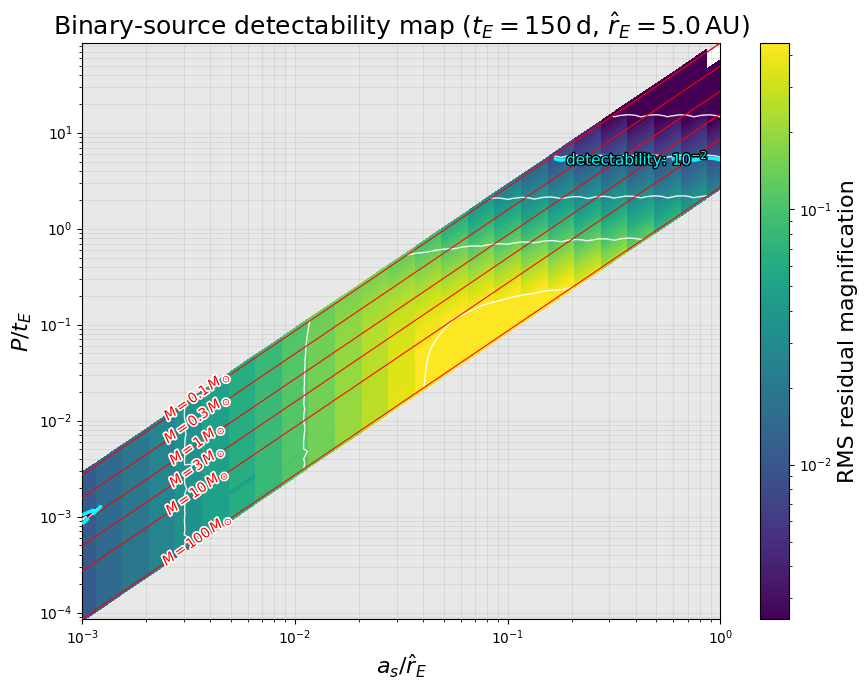

In [54]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patheffects as pe

# ============================================================
# Parámetros del barrido
# ============================================================
tE_true = 150.0
rEhat_AU = 5.0

# Estas grillas DEBEN coincidir con las del script de generación
a_over_RE_grid = np.logspace(-3, 0, 25)
Mtot_grid = np.logspace(-1, 2, 30)   # 0.1 a 100 Msun

# rango "físico" que querés remarcar en la figura
Mmin_phys = 0.1
Mmax_phys = 10.0

pattern = f"/home/anibal-pc/binary_source/results/scan_aRE_Mtot_tE{int(tE_true)}/scan_aRE_*_Mtot_*.npz"
files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# Parseo de índices desde nombre de archivo
# ============================================================
def extract_indices_from_filename(filename):
    """
    Extrae ia e im desde:
    scan_aRE_003_Mtot_015.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_aRE_(\d+)_Mtot_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear índices desde: {base}")
    ia = int(m.group(1))
    im = int(m.group(2))
    return ia, im

# ============================================================
# Función para bordes logarítmicos
# ============================================================
def log_bin_edges(x):
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("Todos los valores deben ser positivos.")
    lx = np.log10(x)
    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5 * (lx[1] - lx[0])
    edges[-1] = lx[-1] + 0.5 * (lx[-1] - lx[-2])
    return 10**edges

# ============================================================
# Reconstrucción de matrices en la grilla (a_over_RE, Mtot)
# ============================================================
Na = len(a_over_RE_grid)
Nm = len(Mtot_grid)

RMS_map = np.full((Na, Nm), np.nan, dtype=float)
P_over_tE_map = np.full((Na, Nm), np.nan, dtype=float)

for fn in files:
    ia, im = extract_indices_from_filename(fn)

    if not (0 <= ia < Na and 0 <= im < Nm):
        continue

    d = np.load(fn, allow_pickle=False)

    P_grid_file = d["P_grid"].astype(float)
    RMS = d["MAXABS"].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    m = SUCCESS & np.isfinite(P_grid_file) & np.isfinite(RMS)
    if not np.any(m):
        continue

    P_day = float(P_grid_file[m][0])
    rms_val = float(RMS[m][0])

    RMS_map[ia, im] = rms_val
    P_over_tE_map[ia, im] = P_day / tE_true

# ============================================================
# Coordenadas de la grilla en el plano (a_s/R_E, P/t_E)
# ============================================================
A_grid, M_grid = np.meshgrid(a_over_RE_grid, Mtot_grid, indexing="ij")
a_AU_grid = A_grid * rEhat_AU
P_yr_grid = np.sqrt(a_AU_grid**3 / M_grid)
P_day_grid = 365.25 * P_yr_grid
P_over_tE_grid = P_day_grid / tE_true

# ============================================================
# Limpieza conservadora de artefactos de borde
# ============================================================
RMS_map[~np.isfinite(RMS_map)] = np.nan
RMS_map[RMS_map <= 0] = np.nan

positive_all = RMS_map[np.isfinite(RMS_map)]
if len(positive_all) == 0:
    raise RuntimeError("No hay valores positivos de RMS para graficar.")

tiny_threshold = np.percentile(positive_all, 0.5)

border_mask = np.zeros_like(RMS_map, dtype=bool)
border_mask[0, :] = True
border_mask[-1, :] = True
border_mask[:, 0] = True
border_mask[:, -1] = True

RMS_map[border_mask & np.isfinite(RMS_map) & (RMS_map < tiny_threshold)] = np.nan

# ============================================================
# Normalización de color
# ============================================================
positive = RMS_map[np.isfinite(RMS_map) & (RMS_map > 0)]
if len(positive) == 0:
    raise RuntimeError("No quedaron valores positivos de RMS luego de limpiar el mapa.")

vmin = np.percentile(positive, 5)
vmax = np.percentile(positive, 95)

# evita problemas si por percentiles quedan iguales
if vmin <= 0 or vmax <= 0 or np.isclose(vmin, vmax):
    vmin = np.nanmin(positive)
    vmax = np.nanmax(positive)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ============================================================
# Figura
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

# ============================================================
# Fondo gris no físico
# ============================================================
x_curve = np.logspace(
    np.log10(a_over_RE_grid.min()),
    np.log10(a_over_RE_grid.max()),
    800
)

def p_over_tE_for_constant_mass(a_over_RE, Mtot_Msun, rEhat_AU, tE_days):
    a_AU = a_over_RE * rEhat_AU
    P_yr = np.sqrt(a_AU**3 / Mtot_Msun)
    P_days = 365.25 * P_yr
    return P_days / tE_days

y_mass_min = p_over_tE_for_constant_mass(x_curve, Mmin_phys, rEhat_AU, tE_true)
y_mass_max = p_over_tE_for_constant_mass(x_curve, Mmax_phys, rEhat_AU, tE_true)

finite_p = P_over_tE_grid[np.isfinite(P_over_tE_grid)]
ymin_plot = np.nanmin(finite_p)
ymax_plot = np.nanmax(finite_p)

# región de masas demasiado bajas: P/tE demasiado grande
ax.fill_between(
    x_curve,
    y_mass_min,
    ymax_plot * np.ones_like(x_curve),
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# región de masas demasiado altas: P/tE demasiado chico
ax.fill_between(
    x_curve,
    ymin_plot * np.ones_like(x_curve),
    y_mass_max,
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# ============================================================
# Mapa coloreado
# ============================================================
a_edges = log_bin_edges(a_over_RE_grid)
m_edges = log_bin_edges(Mtot_grid)

A_edges, M_edges = np.meshgrid(a_edges, m_edges, indexing="ij")
a_AU_edges = A_edges * rEhat_AU
P_yr_edges = np.sqrt(a_AU_edges**3 / M_edges)
P_day_edges = 365.25 * P_yr_edges
P_over_tE_edges = P_day_edges / tE_true

RMS_masked = np.ma.masked_invalid(RMS_map)

pcm = ax.pcolormesh(
    A_edges,
    P_over_tE_edges,
    RMS_masked,
    cmap="viridis",
    norm=norm,
    shading="auto",
    edgecolors="none",
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
    zorder=2
)

# ============================================================
# Contornos con etiquetas
# ============================================================
RMS_for_contour = np.ma.masked_invalid(RMS_map)

contour_levels = np.geomspace(vmin, vmax, 5)

cs = ax.contour(
    A_grid,
    P_over_tE_grid,
    RMS_for_contour,
    levels=contour_levels,
    colors="white",
    linewidths=1.0,
    alpha=0.9,
    norm=norm,
    zorder=3
)

# clabels = ax.clabel(
#     cs,
#     inline=True,
#     fontsize=10,
#     fmt=lambda x: f"{x:.1e}"
# )

# for txt in clabels:
#     txt.set_path_effects([pe.withStroke(linewidth=1.5, foreground="black")])



# ============================================================
# [NUEVO BLOQUE DETECTABILIDAD]
# contorno de detectabilidad para un umbral fijo de RMS
# ============================================================
detect_threshold = 1e-2

if np.nanmin(positive) <= detect_threshold <= np.nanmax(positive):
    cs_detect = ax.contour(
        A_grid,
        P_over_tE_grid,
        RMS_for_contour,
        levels=[detect_threshold],
        colors="cyan",
        linewidths=2.5,
        linestyles="--",
        zorder=5
    )

    detect_labels = ax.clabel(
        cs_detect,
        inline=True,
        fontsize=11,
        fmt={detect_threshold: r"detectability: $10^{-2}$"}
    )

    for txt in detect_labels:
        txt.set_path_effects([pe.withStroke(linewidth=2.0, foreground="black")])
else:
    print(
        f"[INFO] El umbral detect_threshold={detect_threshold:.2e} "
        f"queda fuera del rango del mapa "
        f"[{np.nanmin(positive):.2e}, {np.nanmax(positive):.2e}]. "
        "No se dibuja contorno de detectabilidad."
    )

# ============================================================
# [NUEVO BLOQUE A]
# curvas de masa a dibujar
# ============================================================
mass_list = [0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
mass_colors = plt.cm.tab10(np.linspace(0, 1, len(mass_list)))

# ============================================================
# [NUEVO BLOQUE B]
# función para elegir la posición del label sobre cada curva
# y calcular el ángulo real en pantalla
# ============================================================
def choose_label_on_curve(ax, x_curve, y_curve, ymin_plot, ymax_plot,
                          y_offset_factor=1.02,
                          slope_loglog=1.5, dlogx=0.08,
                          frac_low=0.18):
    """
    Elige una posición para el label sobre la curva, cerca de la parte
    inferior izquierda pero no pegada al borde inferior.

    frac_low controla qué tan abajo se ubica el label dentro del tramo
    visible de la curva:
        frac_low = 0.0  -> punto más bajo visible
        frac_low = 0.18 -> un poco más arriba
        frac_low = 0.30 -> todavía más arriba
    """
    mask = (
        np.isfinite(x_curve) &
        np.isfinite(y_curve) &
        (y_curve >= ymin_plot) &
        (y_curve <= ymax_plot)
    )

    if np.count_nonzero(mask) < 3:
        return None, None, None

    x_valid = x_curve[mask]
    y_valid = y_curve[mask]

    # ============================================================
    # [NUEVO BLOQUE AGREGADO]
    # elegir un punto bajo de la curva, pero no el mínimo exacto
    # ============================================================
    ly = np.log10(y_valid)
    ly_target = ly.min() + frac_low * (ly.max() - ly.min())
    idx = np.argmin(np.abs(ly - ly_target))
    idx = np.clip(idx, 1, len(x_valid) - 2)

    xlab = x_valid[idx]
    y_on_curve = y_valid[idx]
    ylab = y_on_curve * y_offset_factor

    if not (ymin_plot < ylab < ymax_plot):
        ylab = y_on_curve

    # pendiente teórica de Kepler en log-log
    x1 = xlab * 10**(-dlogx / 2.0)
    x2 = xlab * 10**(+dlogx / 2.0)

    y1 = y_on_curve * (x1 / xlab)**slope_loglog
    y2 = y_on_curve * (x2 / xlab)**slope_loglog

    p1 = ax.transData.transform((x1, y1))
    p2 = ax.transData.transform((x2, y2))

    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]

    angle_deg = np.degrees(np.arctan2(dy, dx))

    return xlab, ylab, angle_deg

# ============================================================
# [NUEVO BLOQUE C]
# límites del gráfico
# ============================================================
xmin_plot = a_over_RE_grid.min()
xmax_plot = a_over_RE_grid.max()

# ============================================================
# [NUEVO BLOQUE C0] AGREGADO
# definir escalas y límites ANTES de calcular la rotación de labels
# ============================================================
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(xmin_plot, xmax_plot)
ax.set_ylim(ymin_plot, ymax_plot)

# forzar a Matplotlib a construir la transformación final data -> display
fig.canvas.draw()

# ============================================================
# [NUEVO BLOQUE C1]
# fracciones x y offsets para distribuir labels
# ============================================================
frac_x_list = [0.62, 0.68, 0.74, 0.80, 0.86, 0.92]
y_offset_list = [1.04, 1.035, 1.03, 1.025, 1.02, 1.015]

# ============================================================
# [NUEVO BLOQUE D]
# curvas de masa constante + labels alineados
# ============================================================
for i, Mtot in enumerate(mass_list):
    curve_color = mass_colors[i]
    y_curve = p_over_tE_for_constant_mass(x_curve, Mtot, rEhat_AU, tE_true)

    mask = (
        np.isfinite(y_curve) &
        (y_curve >= ymin_plot) &
        (y_curve <= ymax_plot)
    )

    if np.any(mask):
        ax.plot(
            x_curve[mask],
            y_curve[mask],
            color="red",
            linewidth=0.8,
            alpha=0.95,
            zorder=4
        )

        xlab, ylab, angle_deg = choose_label_on_curve(
            ax,
            x_curve,
            y_curve,
            ymin_plot=ymin_plot,
            ymax_plot=ymax_plot
        )

        print(xlab, ylab, angle_deg)

        if xlab is not None:
            label = rf"$M={Mtot:g}\,M_\odot$"
            txt = ax.text(
                xlab,
                ylab,
                label,
                color="red",
                fontsize=10,
                ha="center",
                va="center",
                rotation=35,
                rotation_mode="anchor",
                zorder=6
            )
            txt.set_path_effects([
                pe.withStroke(linewidth=2.5, foreground="white")
            ])

# remarcar bordes físicos
ax.plot(x_curve, y_mass_min, color="gray", linewidth=1.0, linestyle="--", zorder=1)
ax.plot(x_curve, y_mass_max, color="gray", linewidth=1.0, linestyle="--", zorder=1)

ax.set_xlabel(r"$a_s/\hat{r}_E$", fontsize=16)
ax.set_ylabel(r"$P/t_E$", fontsize=16)
ax.set_title(
    rf"Binary-source detectability map "
    rf"($t_E={tE_true:.0f}\,\mathrm{{d}}$, $\hat r_E={rEhat_AU:.1f}\,\mathrm{{AU}}$)",
    fontsize=18
)

ax.grid(True, which="both", alpha=0.25)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"RMS residual magnification", fontsize=16)

plt.tight_layout()
plt.savefig("/home/anibal-pc/grid_rms.png", dpi=250, bbox_inches="tight")
plt.show()

In [50]:
# np.arctan(3/2)*np.pi/180